<a href="https://colab.research.google.com/github/iras-mpark/AIB2004/blob/main/week2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Step  | V의 상태 가치                       | U의 상태 가치                       | 최대 오차 ||V - U||     
----------------------------------------------------------------------------------------------------
0     | [0.00, 0.00, 0.00]             | [100.00, 100.00, 100.00]       | 100.0000
1     | [1.00, 2.00, 0.00]             | [91.00, 92.00, 90.00]          | 90.0000
2     | [2.08, 2.99, 0.00]             | [83.08, 83.99, 81.00]          | 81.0000
3     | [3.04, 3.85, 0.00]             | [75.94, 76.75, 72.90]          | 72.9000
4     | [3.88, 4.61, 0.00]             | [69.49, 70.22, 65.61]          | 65.6100
5     | [4.62, 5.27, 0.00]             | [63.67, 64.32, 59.05]          | 59.0490
6     | [5.28, 5.86, 0.00]             | [58.42, 59.00, 53.14]          | 53.1441
7     | [5.85, 6.38, 0.00]             | [53.68, 54.21, 47.83]          | 47.8297
8     | [6.36, 6.84, 0.00]             | [49.41, 49.88, 43.05]          | 43.0467
9     | [6.81, 7.24, 0.00]             | [45.55, 45.98, 38.74]   

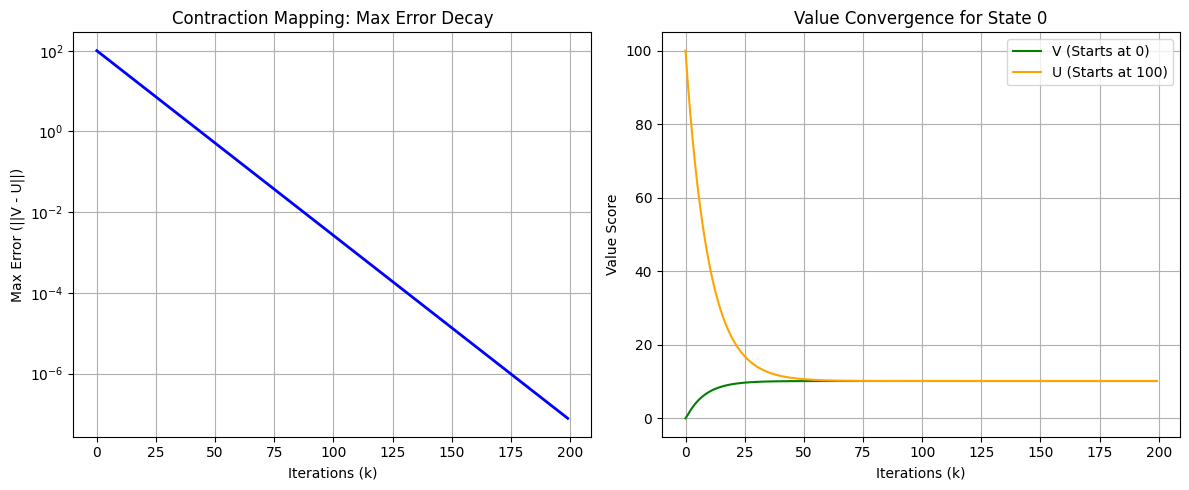

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 환경 세팅 (상태 3개, 행동 2개)
num_states = 3
num_actions = 2
gamma = 0.9

R = np.array([
    [1.0, 0.0],
    [0.0, 2.0],
    [0.0, 0.0]
])

P = np.zeros((num_states, num_actions, num_states))
P[0, 0, :] = [0.8, 0.2, 0.0]; P[0, 1, :] = [0.1, 0.9, 0.0]
P[1, 0, :] = [0.0, 0.8, 0.2]; P[1, 1, :] = [0.7, 0.2, 0.1]
P[2, 0, :] = [0.0, 0.0, 1.0]; P[2, 1, :] = [0.0, 0.0, 1.0]

# 벨만 최적화 연산자 함수
def bellman_optimality_operator(V_k, P, R, gamma):
    V_next = np.zeros(num_states)
    for s in range(num_states):
        q_values = np.zeros(num_actions)
        for a in range(num_actions):
            expected_future_value = np.sum(P[s, a, :] * V_k)
            q_values[a] = R[s, a] + gamma * expected_future_value
        V_next[s] = np.max(q_values)
    return V_next

# 2. 서로 다른 초기화
V = np.zeros(num_states)         # V는 0에서 시작
U = np.ones(num_states) * 100.0  # U는 100에서 시작

# 3. 데이터 수집 및 출력 루프
max_iterations = 200
print_limit = 50  # 처음 50번까지만 텍스트로 출력

errors = []
v_state0_values = []
u_state0_values = []

print(f"{'Step':<5} | {'V의 상태 가치':<30} | {'U의 상태 가치':<30} | {'최대 오차 ||V - U||':<20}")
print("-" * 100)

for i in range(max_iterations):
    max_error = np.max(np.abs(V - U))

    # 그래프를 위한 데이터 저장
    errors.append(max_error)
    v_state0_values.append(V[0])
    u_state0_values.append(U[0])

    # 텍스트 출력 (처음 15번까지만)
    if i < print_limit:
        v_str = f"[{V[0]:.2f}, {V[1]:.2f}, {V[2]:.2f}]"
        u_str = f"[{U[0]:.2f}, {U[1]:.2f}, {U[2]:.2f}]"
        print(f"{i:<5} | {v_str:<30} | {u_str:<30} | {max_error:.4f}")
    elif i == print_limit:
        print(f"... (중략, 총 {max_iterations}번 반복) ...")

    # 가치 업데이트
    V = bellman_optimality_operator(V, P, R, gamma)
    U = bellman_optimality_operator(U, P, R, gamma)

print("-" * 100)
print(f"최종(Step {max_iterations}) 수렴 결과:")
print(f"V*: [{V[0]:.4f}, {V[1]:.4f}, {V[2]:.4f}]")
print(f"U*: [{U[0]:.4f}, {U[1]:.4f}, {U[2]:.4f}]")
print(f"최종 오차: {np.max(np.abs(V - U)):.6f}")

# 4. 시각화 (Matplotlib)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 그래프 1: 최대 오차의 지수적 감소
ax1.plot(range(max_iterations), errors, color='blue', linewidth=2)
ax1.set_title('Contraction Mapping: Max Error Decay')
ax1.set_xlabel('Iterations (k)')
ax1.set_ylabel('Max Error (||V - U||)')
ax1.set_yscale('log')  # 로그 스케일 적용
ax1.grid(True)

# 그래프 2: 상태 0의 가치 수렴 과정
ax2.plot(range(max_iterations), v_state0_values, label='V (Starts at 0)', color='green')
ax2.plot(range(max_iterations), u_state0_values, label='U (Starts at 100)', color='orange')
ax2.set_title('Value Convergence for State 0')
ax2.set_xlabel('Iterations (k)')
ax2.set_ylabel('Value Score')
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()